# Load a pretrained model and perform inference

This notebook shows how to load the available models in the folder `model_hub`, already pretrained using [this dataset](https://github.com/matteobonotto/ITERlike-equilibrium-dataset), and check their accouracy in terms of reconstructing the flux and the Grad-Shafranov operators.

In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import numpy as np
from copy import deepcopy
from time import time
import torch
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import pickle
import json

from planetequil import PlaNet
from planetequil.utils import read_h5_numpy, dummy_planet_input_np, dummy_planet_input_tensor, load_config
from planetequil.data import PlaNetDataset, Scaler
from planetequil.train import DataModule, collate_fun
from planetequil.config import Config
from planetequil.plot import contourf

from torch.utils.data import DataLoader

In [25]:
dataset = PlaNetDataset(path="planet_sample_dataset.h5", scale_inputs=False)
dataloader = DataLoader(
    dataset=dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fun,
    num_workers=0,
    drop_last=True,
)

Loading model from ../model_hub/planet


100%|██████████| 4/4 [00:00<00:00,  7.83it/s]


Loading model from ../model_hub/planet_slim


100%|██████████| 4/4 [00:00<00:00, 67.66it/s]


Loading model from ../model_hub/planet_slim_mlp


100%|██████████| 4/4 [00:00<00:00, 121.68it/s]


Loading model from ../model_hub/planet_no_physics_informed


100%|██████████| 4/4 [00:00<00:00, 57.49it/s]


planet                       -0.822144
planet_slim                  -1.089235
planet_slim_mlp              -1.467218
planet_no_physics_informed    3.149339
dtype: float32


'\nloss = {}\nfor model_path in Path("../model_hub").iterdir():\n    if \'planet\' not in model_path.name:\n        continue\n    # print(model_path.name)\n    model = PlaNet.from_pretrained(path=model_path)\n    loss[model_path.name] = []\n    pbar = tqdm(dataloader, total=len(dataloader))\n    for i, batch in enumerate(pbar):\n        batch = [x.to(model.device) for x in batch]\n        measures, flux, rhs, RR, ZZ, L_ker, Df_ker = batch\n        inputs = {\n            "measures":measures,\n            "rr":RR,\n            "zz":ZZ,\n        }\n        pred = model(**inputs)\n        loss_ = (pred - flux).mean(dim=1).mean(dim=1).cpu().numpy()\n        loss[model_path.name].extend(loss_)\n\nloss_df = pd.DataFrame(loss)\nprint(100*loss_df.mean())\nloss_df.hist(figsize=(10,10))\n'

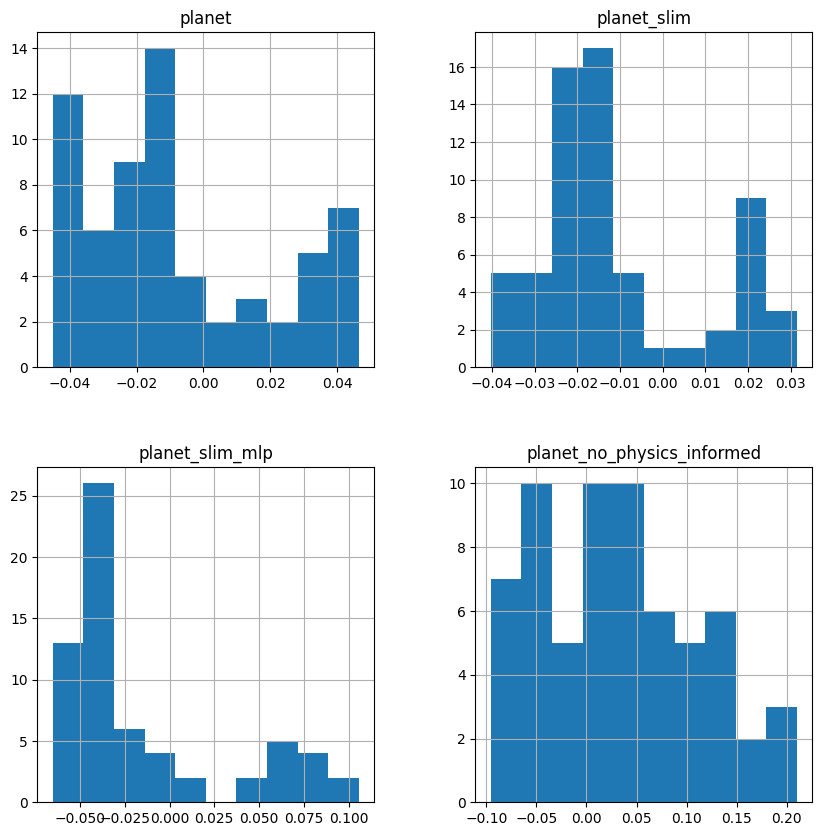

In [ ]:
loss = {}
for model_path in Path("../model_hub").iterdir():
    if 'planet' not in model_path.name:
        continue
    # print(model_path.name)
    model = PlaNet.from_pretrained(path=model_path)
    loss[model_path.name] = []
    pbar = tqdm(dataloader, total=len(dataloader))
    for i, batch in enumerate(pbar):
        batch = [x.to(model.device) for x in batch]
        measures, flux, rhs, RR, ZZ, L_ker, Df_ker = batch
        inputs = {
            "measures":measures,
            "rr":RR,
            "zz":ZZ,
        }
        pred = model(**inputs)
        loss_ = (pred - flux).mean(dim=1).mean(dim=1).cpu().numpy()
        loss[model_path.name].extend(loss_)

loss_df = pd.DataFrame(loss)
print(100*loss_df.mean())
loss_df.hist(figsize=(10,10))

In [38]:
# data = read_h5_numpy("planet_sample_dataset.h5")
data = read_h5_numpy("planet_sample_dataset.h5")


loss_flux = {}
loss_gsope = {}
batch_size = 16
n_tot = data['measures'].shape[0]//batch_size
for model_path in Path("../model_hub").iterdir():
    if 'planet' not in model_path.name:
        continue
    model = PlaNet.from_pretrained(
        path=model_path, 
    )
    for i in tqdm(range(n_tot), total=n_tot):
        loss_flux[model_path.name] = []
        loss_gsope[model_path.name] = []

        idx = slice(i*batch_size, (i+1)*batch_size)

        #this step is required because the implace scaling will otherwise edit the 
        # data in the dataset
        inputs = {
                "measures" : deepcopy(data['measures'][idx, ...]),
                "rr" : data['RR_grid'],
                "zz" : data['ZZ_grid']
            }
        flux = model(**inputs)

        gs_ope = model.compute_gs_operator(
            flux=flux,
            rr=data['RR_grid'],
            zz=data['ZZ_grid'],
        )

        loss_flux[model_path.name].extend(
            np.mean(np.mean(flux-data['flux'][idx, ...], axis=1), axis=-1)
        )
        loss_gsope[model_path.name].extend(
            np.mean(np.mean(gs_ope-data['rhs'][idx,1:-1,1:-1], axis=1), axis=-1)
        )


loss_flux_df = pd.DataFrame([abs(x) for x in loss_flux])
print(" Mean error for the flux ")
print(100*loss_flux_df.mean())#/loss_flux_df.abs().max())

print('\n')
print(" Mean error for the GS operator ")
loss_gsope_df = pd.DataFrame([abs(x) for x in loss_gsope])
print(100*loss_gsope_df.mean())#/loss_flux_df.abs().max())


loss_gsope_df.plot.bar(figsize=(10,10))
loss_df.hist(figsize=(10,10))


Loading model from ../model_hub/planet


100%|██████████| 4/4 [00:00<00:00,  8.26it/s]


Loading model from ../model_hub/planet_slim


100%|██████████| 4/4 [00:00<00:00, 55.90it/s]


Loading model from ../model_hub/planet_slim_mlp


100%|██████████| 4/4 [00:00<00:00, 69.41it/s]


Loading model from ../model_hub/planet_no_physics_informed


100%|██████████| 4/4 [00:00<00:00, 50.86it/s]


TypeError: bad operand type for abs(): 'str'

/var/folders/1z/0p630gzs7zv8cgz4xtmr08pr0000gn/T/ipykernel_14101/1364891792.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10' if num_cols <= 10 else 'tab20')


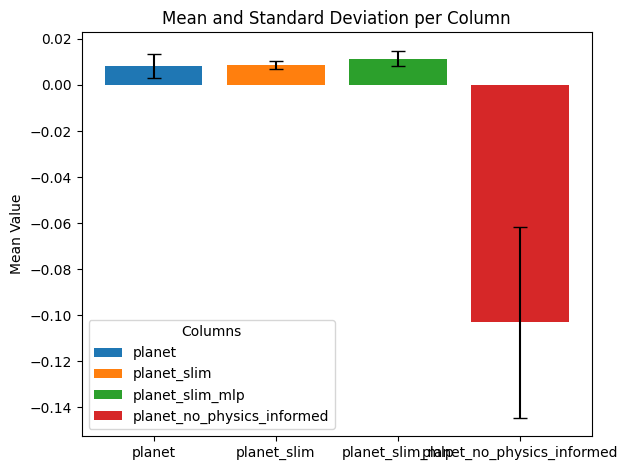

In [35]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def barplot(df: pd.DataFrame):
    means = df.mean()
    stds = df.std()
    num_cols = means.shape[0]

    cmap = cm.get_cmap('tab10' if num_cols <= 10 else 'tab20')
    colors = [cmap(i % cmap.N) for i in range(num_cols)]

    # Plot
    fig, ax = plt.subplots()
    bars = ax.bar(df.columns, means, yerr=stds, capsize=5, color=colors)

    # Add legend (one entry per bar/column)
    ax.legend(bars, df.columns, title="Columns")

    # Add labels
    ax.set_ylabel('Mean Value')
    ax.set_title('Mean and Standard Deviation per Column')
    plt.tight_layout()
    plt.show()

barplot(loss_gsope_df)